In [1]:
import pandas as pd, numpy as np, re
import matplotlib.pyplot as plt

## Importing the CSVs

In [2]:
perf    = pd.read_csv("Fund Performance since 1983.csv",   low_memory=False)
info    = pd.read_csv("Fund Details.csv",                  low_memory=False)
details = pd.read_csv("Manger Details.csv",                low_memory=False)
print(len(perf), len(info), len(details))


363083 75786 32792


In [3]:
info[info["fund_id"]== 15925]

,firm_id,fund_id,fund_name,firm_name,vintage,fund_type,fundraising_launch_date,local_currency,target_size_lc,target_size_usd,...,fund_number_overall,fund_number_series,fund_structure,geographic_scope,region,industry,placement_agents,law_firm,administrator,auditor
8161,22472,15925,BonVenture II,BonVenture,2009.0,Venture (General),NaN,EUR,NaN,NaN,...,2.0,2.0,NaN,NaN,West Europe,Diversified,Not Used,NaN,NaN,NaN


## Coercing

In [4]:
num_info = [c for c in info.columns if c.endswith(("usd","eur","pcent"))]
num_perf = [c for c in perf.columns if c.endswith(("usd","eur","pcent"))] + ["multiple"]

info[num_info] = info[num_info].apply(pd.to_numeric, errors="coerce")
perf[num_perf] = perf[num_perf].apply(pd.to_numeric, errors="coerce")

## Keeping only post 2009 vintage and only VC funds (not buyout, growth,etc.)

In [5]:
VC_CORE = {"Venture (General)", "Early Stage", "Early Stage: Seed", "Early Stage: Start-up"}

info_vc = (info
           .loc[info["fund_type"].isin(VC_CORE)]               # Filter auf Fund-Typ
           .assign(vintage=lambda d: pd.to_numeric(d["vintage"], errors="coerce"))
           .loc[lambda d: (d["vintage"] >= 2009) & (d["vintage"] <= 2017)]               # Vintage-Cut
           .copy())


## Merging Datasets to get the firm location and selecting only the last performance value

In [6]:
info_vc = (
    info_vc
        .merge(details[["firm_id", "firmcountry"]], on="firm_id", how="left")
        .drop(columns=["region"])            # region vollständig entfernen
)

print("Firmcountry missing share:",
      info_vc["firmcountry"].isna().mean().round(3))


Firmcountry missing share: 0.025


In [7]:
perf_latest = (perf.sort_values("date_reported")
                    .groupby("fund_id", as_index=False)
                    .tail(1))                       # keep most-recent row per fund

df = perf_latest.merge(info_vc, on="fund_id", how="inner")
print("Rows in analysis DataFrame:", len(df))


Rows in analysis DataFrame: 1105


## Creating the Europe/US dummies and dropping the rest

In [8]:
# Liste europäischer Länder (ggf. erweitern)
EUROPE = {
    'Austria','Belgium','Bulgaria','Croatia','Czech Republic','Cyprus','Denmark',
    'Estonia','Finland','France','Germany','Greece','Hungary',
    'Ireland','Italy','Latvia','Lithuania','Luxembourg','Malta','Netherlands',
    'Norway','Poland','Portugal','Romania','Slovakia','Slovenia',
    'Spain','Sweden','Switzerland','United Kingdom','UK'
}

US = {'United States', 'US'}

def hq_location(country):
    if pd.isna(country):         return 'Other'   # Unknown zählt zu Other
    if country in US:            return 'US'
    if country in EUROPE:        return 'Europe'
    return 'Other'

df["hq_location"] = df["firmcountry"].apply(hq_location)

# Drop all rows whose mapped HQ location is "Other"
df = df[df["hq_location"] != "Other"].copy()

# (Optional) reset the index if you want a clean sequential index
df.reset_index(drop=True, inplace=True)

## Creating TVPI 

In [9]:
df["tvpi_pcent"] = df["distr_dpi_pcent"] + df["value_rvpi_pcent"]

## Creating specialist Dummy

In [10]:
df["industry_specialisation"] = df["industry"].apply(
    lambda x: (
        "Generalist"
        if pd.notna(x) and ("diversified" in x.lower() or (x.count(";") + 1) > 3)
        else ("Specialist" if pd.notna(x) else np.nan)
    )
)

In [11]:
pd.set_option('display.max_rows', 740)
pd.set_option("display.max_colwidth", None)   # show full text in each cell

df[["industry", "industry_specialisation"]]

,industry,industry_specialisation
0,Diversified,Generalist
1,Biotechnology;Healthcare;Medical Devices & Equipment;Pharmaceuticals,Generalist
2,Information Technology;Electronics;Internet;IT Infrastructure;IT Security/Cybersecurity;Telecoms & Media;Media;Telecoms,Generalist
3,Transportation Services;Energy & Utilities;Power & Utilities;Renewable Energy;Environmental Services;Information Technology;Semiconductors;Chemicals;Materials,Generalist
4,Renewable Energy,Specialist
5,Biotechnology;Healthcare;Medical Devices & Equipment;Pharmaceuticals,Generalist
6,Information Technology;Internet;Software,Specialist
7,Information Technology;Internet;IT Infrastructure;Software,Generalist
8,IT Security/Cybersecurity;Semiconductors;Software,Specialist
9,Diversified;Information Technology,Generalist


In [12]:
df["industry_specialisation"].value_counts()

industry_specialisation
Generalist    455
Specialist    278
Name: count, dtype: int64

        ≤1 industries  ≤2 industries  ≤3 industries  ≤4 industries  \
Region                                                               
Europe            0.0          0.089          0.184          0.346   
US                0.0          0.108          0.204          0.390   

        ≤5 industries  ≤6 industries  ≤7 industries  
Region                                               
Europe          0.486          0.609          0.665  
US              0.511          0.583          0.634  


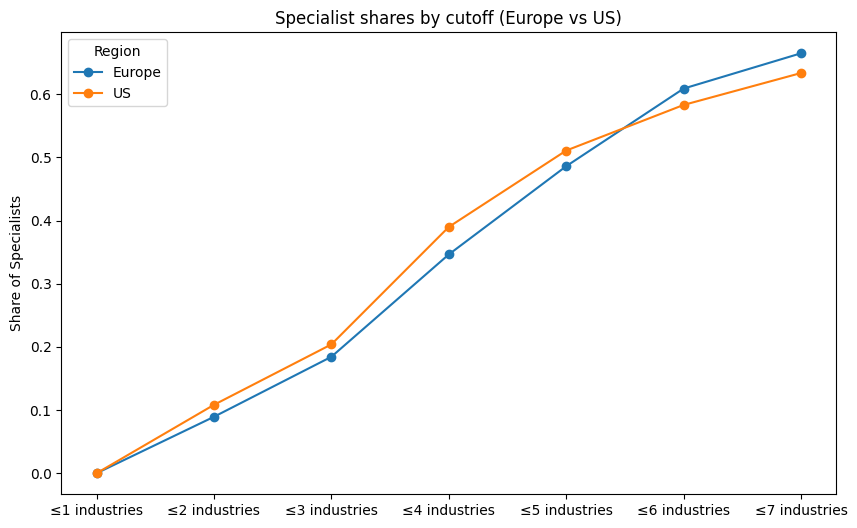

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- classification helper ---
def classify_industry(x, cutoff=3):
    """Generalist if industry contains 'diversified' OR #industries >= cutoff.
       Otherwise Specialist."""
    if pd.isna(x):
        return np.nan
    industries = [i.strip() for i in str(x).split(";") if i.strip()]
    n = len(industries)
    if "diversified" in x.lower() or n >= cutoff:
        return "Generalist"
    return "Specialist"

# --- function to compute shares for one cutoff ---
def specialist_share_table(df, cutoff=3):
    tmp = df.copy()
    tmp["industry_specialisation"] = tmp["industry"].apply(lambda x: classify_industry(x, cutoff))
    
    shares = (tmp.groupby(["hq_location","industry_specialisation"])
                 .size()
                 .unstack(fill_value=0))
    # ensure both columns exist
    for col in ["Specialist","Generalist"]:
        if col not in shares.columns:
            shares[col] = 0
    shares["Total"] = shares["Specialist"] + shares["Generalist"]
    shares["Specialist_share"] = shares["Specialist"] / shares["Total"]
    return shares[["Total","Specialist","Generalist","Specialist_share"]]

# --- loop over cutoffs 1–7 ---
share_tables = {}
for cutoff in range(1,8):
    share_tables[cutoff] = specialist_share_table(df, cutoff)

# Combine into one summary table (specialist shares only)
combined = pd.DataFrame({
    cutoff: tbl["Specialist_share"] for cutoff, tbl in share_tables.items()
})
combined.columns = [f"≤{c} industries" for c in combined.columns]
combined.index.name = "Region"

print(combined.round(3))

# Optional: visualize as line plot
combined.T.plot(figsize=(10,6), marker="o")
plt.ylabel("Share of Specialists")
plt.title("Specialist shares by cutoff (Europe vs US)")
plt.show()


## Creating the fund age variable

In [14]:
df["fund_age_at_report"] = pd.to_datetime(df["date_reported"]).dt.year - df["vintage_x"]

## Keeping only the relevant columns

In [15]:
df["vintage"] = df["vintage_x"]

In [16]:
df = df[["firm_id", "fund_id", "date_reported", "vintage", "distr_dpi_pcent","net_irr_pcent", "tvpi_pcent", "value_rvpi_pcent", "multiple","fund_type", "final_size_usd", "fund_status", "fund_focus", "hq_location", "industry", "firmcountry", "industry_specialisation", "fund_age_at_report"]]

In [17]:
df

,firm_id,fund_id,date_reported,vintage,distr_dpi_pcent,net_irr_pcent,tvpi_pcent,value_rvpi_pcent,multiple,fund_type,final_size_usd,fund_status,fund_focus,hq_location,industry,firmcountry,industry_specialisation,fund_age_at_report
0,22472,15925,2009-12-31,2009,0.00,-72.46,85.00,85.00,0.85,Venture (General),14.69,Closed,Europe,Europe,Diversified,Germany,Generalist,0
1,3797,13136,2010-09-30,2009,0.00,NaN,115.00,115.00,1.15,Venture (General),105.39,Closed,Europe,Europe,Biotechnology;Healthcare;Medical Devices & Equipment;Pharmaceuticals,Switzerland,Generalist,1
2,22042,15720,2011-03-31,2010,0.00,NaN,100.00,100.00,1.00,Early Stage,6.78,Closed,Europe,Europe,Information Technology;Electronics;Internet;IT Infrastructure;IT Security/Cybersecurity;Telecoms & Media;Media;Telecoms,UK,Generalist,1
3,21527,18800,2011-12-31,2010,0.00,0.00,100.00,100.00,1.00,Early Stage: Start-up,138.60,Closed,Europe,Europe,Transportation Services;Energy & Utilities;Power & Utilities;Renewable Energy;Environmental Services;Information Technology;Semiconductors;Chemicals;Materials,France,Generalist,1
4,6638,24071,2012-06-30,2011,0.15,-16.87,74.85,74.70,0.75,Venture (General),300.00,Closed,North America,US,Renewable Energy,US,Specialist,1
5,136,18208,2012-12-31,2011,0.00,-13.44,74.00,74.00,0.74,Venture (General),149.85,Closed,Europe,Europe,Biotechnology;Healthcare;Medical Devices & Equipment;Pharmaceuticals,Belgium,Generalist,1
6,14,28037,2012-12-31,2011,0.00,-2.85,96.32,96.32,0.96,Venture (General),33.70,Closed,North America,US,Information Technology;Internet;Software,US,Specialist,1
7,12516,15924,2013-03-31,2009,211.00,106.60,265.90,54.90,2.66,Early Stage,5.10,Closed,North America,US,Information Technology;Internet;IT Infrastructure;Software,US,Generalist,4
8,413,18158,2013-03-31,2009,55.00,18.76,138.80,83.80,1.39,Venture (General),25.00,Closed,North America,US,IT Security/Cybersecurity;Semiconductors;Software,US,Specialist,4
9,24333,16815,2013-06-30,2010,5.93,NaN,124.73,118.80,1.25,Venture (General),41.00,Closed,North America,US,Diversified;Information Technology,US,Generalist,3


In [18]:
df.to_csv("final_data_2009_2017.csv", index=False)